# oLIMpus Tutorial #5 — Burstiness in the LIM shot noise

Companion notebook for **Kovetz, Lazare, Libanore, Muñoz & Vanzan (2026)**,
*"When galaxies burst: enhanced shot-noise for line-intensity mapping in the JWST era"*
([arXiv:2605.13967](https://arxiv.org/abs/2605.13967)).

This notebook generates every quantitative number and every figure in the Letter. Unlike the
original companion notebook, it uses **released oLIMpus code paths only**:

| the Letter's notebook did | this notebook does |
|---|---|
| monkey-patched `zeus21.sfrd.SFR_II` to install the M26 SFE | passes the M26 SFE as ordinary `Astro_Parameters` — it is *exactly* representable (§1.2) |
| re-implemented $V_\lambda$, $V_{12}$ with `scipy.quad` | `oLIMpus.burstiness_LIM`, in closed form |
| re-implemented $\bar I_\nu$, $b_{\rm eff}$, $P_{\rm shot}\vert_{\rm det}$, $\mathcal{B}$, $\mathcal{R}$ by hand | `Inu_bar`, `Deltasq_LIM_lin`, `shot_noise_det`, `B_lambda()`, `R_cross()` |
| built a second HMF interpolator to reach $z=3$ | `Cosmo_Parameters(zmin_CLASS=2.5)` |

Nothing here is patched, shadowed or re-derived, so what you see is what any user of the
release gets.

> **One result changed, and you should look at it.** Reproducing the Letter's Fig. 3 and
> Appendix Fig. 7 with the M26 SFE *actually applied* gives
> $\mathcal{B}_{{\rm H}\alpha}=7.45$ and $\mathcal{B}_{\rm [CII]}=6.94$, not the 5.7 and 4.3
> quoted there. Those quoted values are what oLIMpus's **default** SFE gives (5.712 and
> 4.271 — reproduced exactly below). §8 works through why, and what it does and does not
> affect. Table I is unaffected.

## Contents

1. **Setup** — cosmology, the M26 SFE as `Astro_Parameters`, line definitions
2. **Burstiness machinery** — OU correlator, $V_\lambda$, $\sigma_{\xi,\lambda}^2$, all from `burstiness_LIM`
3. **Mass-integrated boost** — `B_lambda()` on oLIMpus's own HMF and $\bar L_\lambda$
4. **Monte-Carlo verification of Eq. 5**, and **4b** the top-hat vs exponential Green's function
5. **Figure 1** — per-halo boost
6. **Figure 2** — $\mathcal{B}_\lambda$ vs $\sigma_{\rm PS}$
7. **Figure 3** — cross-correlation diagnostic $\mathcal{R}$
8. **Figure 4** — $\Delta^2(k)$ for H$\alpha$ at $z\approx6$ with and without burstiness
9. **Figure 5** — redshift tomography of $\mathcal{B}_\lambda(z)$
10. **Table I** — boost values
11. **Appendix A** — line-shape dependence (Fig. 6, Table II, Fig. 7)
12. **Appendix C** — the $\sigma_{\rm PS}\gtrsim3$ cap test


In [1]:
# ----------------------------------------------------------------------------- #
# Plot style. oLIMpus.analysis sets text.usetex=True globally on import; that
# needs a working LaTeX installation. Set USE_TEX = True if you have one --
# the figures below are laid out for a single-column paper figure either way.
# ----------------------------------------------------------------------------- #
USE_TEX = True

import matplotlib as mpl
import matplotlib.pyplot as plt

colors = ['#001219', '#005f73', '#0a9396', '#94d2bd', '#e9d8a6',
          '#ee9b00', '#ca6702', '#bb3e03', '#ae2012', '#9b2226']

mpl.rcParams['axes.prop_cycle'] = mpl.cycler(color=colors)
plt.rcParams.update({
    "text.usetex": USE_TEX,
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
    "mathtext.fontset": "stix",
    "figure.figsize": (5.7, 4.5),
    "figure.dpi": 110,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "lines.linewidth": 2,
    "axes.linewidth": 1.1,
    "xtick.direction": "in", "ytick.direction": "in",
    "xtick.top": True, "ytick.right": True,
    "legend.frameon": False,
    "font.size": 13, "axes.titlesize": 13, "axes.labelsize": 13,
    "xtick.labelsize": 11, "ytick.labelsize": 11, "legend.fontsize": 11,
})


---
## 1. Setup

### 1.1 What the model says

The SFR of a galaxy in a halo of mass $M_h$ at cosmic time $t$ is modelled as a
**mean-anchored** lognormal driven by a stationary Ornstein–Uhlenbeck process (M26 Eq. 1):

$$\dot M_\star(M_h,t)=\overline{\dot M_\star}(M_h,t)\,e^{x(M_h,t)-\sigma_x^2(M_h)/2},\qquad
\xi_x(M_h,\Delta t)=\sigma_x^2(M_h)\,e^{-|\Delta t|/\tau_{\rm PS}},\qquad
\sigma_x^2=\frac{\sigma_{\rm PS}^2}{2}.$$

The line luminosity is that SFR convolved with the line's stellar-population-synthesis
Green's function, approximated by a top hat of effective width $t_\lambda$. Because the mean
is anchored by construction, $\bar I_\nu$, $b_{\rm eff}$ and the **clustering term are
unchanged**; only the second moment moves (Letter Eqs. 5–6):

$$V_\lambda(M_h)=\frac{2}{t_\lambda^2}\int_0^{t_\lambda}\!\!{\rm d}s\,(t_\lambda-s)
\Big[e^{\sigma_x^2(M_h)e^{-s/\tau_{\rm PS}}}-1\Big],\qquad
P_{\rm shot}=\mathcal{X}_\lambda^2\!\int\!{\rm d}M_h\frac{{\rm d}n}{{\rm d}M_h}\bar L_\lambda^2\,
\big[1+V_\lambda\big].$$

That asymmetry — clustering untouched, shot noise boosted — is the most counter-intuitive
part of the formalism, and §8 checks it explicitly in the code.

### M26 burstiness parameters and effective line timescales

Compromise central values derived from Muñoz et al. 2026
([arXiv:2601.07912](https://arxiv.org/abs/2601.07912)). M26's pivot mass is $10^{10}M_\odot$,
where they report $\sigma_{\rm PS}\approx2.5$–$3$ (Endsley sample) or $2.1$ (Simmonds
sample). Propagating the slope $d\sigma_{\rm PS}/d\log_{10}M_h\approx-0.5$ down to our pivot
$10^{11}M_\odot$ and rounding gives

- $\sigma_{\rm PS}(M_h{=}10^{11}M_\odot)=2.0\pm0.3$
- $d\sigma_{\rm PS}/d\log_{10}M_h=-0.5$ ($\sigma_{\rm PS}$ **grows toward smaller halos**)
- $\tau_{\rm PS}=25$ Myr

These are the `Line_Parameters` defaults, so `BURSTY_FLAG=True` alone reproduces the Letter.


In [2]:
import numpy as np
import time
from scipy.integrate import quad

from zeus21 import cosmology, Z_init, SFRD_class
from zeus21.inputs import User_Parameters, Cosmo_Parameters, Astro_Parameters
from oLIMpus.inputs_LIM import Line_Parameters
from oLIMpus import coefficients_LIM, correlations_LIM, burstiness_LIM, inputs_LIM

# ---- the Letter's palette, kept so the figures match the published ones ------- #
LINE_COLOR = {'Halpha': '#2ca02c', '[CII]': '#1f77b4',
              'CO(1-0)': '#ff7f0e', 'UV cont.': '#d62728'}
LINE_TEX = {'Halpha': r'$\mathrm{H}\alpha$', '[CII]': r'$[\mathrm{C}\,\mathrm{II}]$',
            'CO(1-0)': r'$\mathrm{CO}(1\!-\!0)$', 'UV cont.': r'$\mathrm{UV~cont.}$'}

# ---- M26 burstiness parameters (the Line_Parameters defaults) ---------------- #
sigPS_pivot, sigPS_pivot_err = 2.0, 0.3
log10M_pivot, dsigPS_dlog10M = 11.0, -0.5
tauPS_Myr = 25.0

# ---- effective top-hat window widths, Table I of the Letter ------------------ #
t_lambda = {'Halpha': 7.0, '[CII]': 50.0, 'CO(1-0)': 80.0, 'UV cont.': 100.0}
for name, t in t_lambda.items():
    print(f"  {name:<9}: t_lambda = {t:>5.1f} Myr")

print()
for lm in (9, 10, 11, 12):
    print(f"  sigma_PS at log10(M_h) = {lm}: "
          f"{sigPS_pivot + dsigPS_dlog10M*(lm - log10M_pivot):.2f}")


oLIMpus version 2.0
zeus21 version 0.1.dev0
  Halpha   : t_lambda =   7.0 Myr
  [CII]    : t_lambda =  50.0 Myr
  CO(1-0)  : t_lambda =  80.0 Myr
  UV cont. : t_lambda = 100.0 Myr

  sigma_PS at log10(M_h) = 9: 3.00
  sigma_PS at log10(M_h) = 10: 2.50
  sigma_PS at log10(M_h) = 11: 2.00
  sigma_PS at log10(M_h) = 12: 1.50


### 1.2 The M26 SFE is an ordinary `Astro_Parameters`

The Letter's notebook substituted the M26 double power law
$f_\star(M_h)=2\epsilon/[(M_h/M_p)^{\alpha}+(M_h/M_p)^{\beta}]$ with
$(\epsilon,M_p,\alpha,\beta)=(10^{-1.5},10^{11.1},0.7,-0.4)$ by monkey-patching
`zeus21.sfrd.SFR_II`. That is unnecessary: Zeus21's GALLUMI-like SFE is

$$f_\star=\frac{\Omega_b}{\Omega_m}\,\frac{2\epsilon_\star}
{(M_h/M_c)^{-\alpha_\star}+(M_h/M_c)^{-\beta_\star}},$$

which is the *same function* with $\{-\alpha_\star,-\beta_\star\}=\{\alpha,\beta\}$, and its
exponential accretion is $\dot M_h=\alpha_g M_h(1+z)H(z)$ with
`ALPHA_accretion_exponential = 0.79` $=\alpha_g$. So the M26 SFE is

```python
Astro_Parameters(epsstar=10**-1.5, Mc=10**11.1, alphastar=0.4, betastar=-0.7,
                 Mturn_fixed=1e-10, accretion_model='exp')
```

`Mturn_fixed=1e-10` switches off the atomic-cooling duty cycle, matching the Letter's SFR
which has no $f_{\rm duty}$. The cell below checks the agreement.


In [3]:
UP = User_Parameters(precisionboost=1.0, FLAG_FORCE_LINEAR_CF=False, MIN_R_NONLINEAR=0.5,
                     MAX_R_NONLINEAR=200.0, FLAG_DO_DENS_NL=False, FLAG_WF_ITERATIVE=True)

t0 = time.time()
CP = Cosmo_Parameters(UserParams=UP, omegab=0.0223828, omegac=0.1201075, h_fid=0.67810,
                      As=2.100549e-09, ns=0.9660499, tau_fid=0.05430842, HMF_CHOICE="ST")
HMF = cosmology.HMF_interpolator(UserParams=UP, CosmoParams=CP)
print(f"cosmology + HMF: {time.time()-t0:.1f} s")

ASTRO_COMMON = dict(accretion_model='exp', dlog10epsstardz=0.0,
                    quadratic_SFRD_lognormal=True, USE_LW_FEEDBACK=False,
                    fesc10=0.1, alphaesc=0., L40_xray=3.0, E0_xray=500.,
                    alpha_xray=-1.0, Emax_xray_norm=2000)

M26_SFE = dict(epsstar=10**(-1.5), Mc=10**11.1, alphastar=0.4, betastar=-0.7,
               Mturn_fixed=1e-10)
DEFAULT_SFE = dict(epsstar=0.1, Mc=3e11, alphastar=0.5, betastar=-0.5, Mturn_fixed=None)

AP = Astro_Parameters(CosmoParams=CP, **M26_SFE, **ASTRO_COMMON)
z_Init = Z_init(UserParams=UP, CosmoParams=CP)
SFRD_Init = SFRD_class(UP, CP, AP, HMF, z_Init)

# ---- check against the Letter's hard-coded M26 SFR --------------------------- #
def M26_SFR_letter(M_h, z, f_b=0.158, alpha_g=0.79, h=0.6766, Om=0.30966):
    """The expression the Letter's notebook monkey-patched in."""
    H_invs = 100*h*(1e3/3.0857e22)*np.sqrt(Om*(1+z)**3 + (1-Om))
    Mp, eps, alpha, beta = 10**11.1, 10**(-1.5), 0.7, -0.4
    f_star = 2*eps/((M_h/Mp)**alpha + (M_h/Mp)**beta)
    return f_star*f_b*alpha_g*M_h*(1+z)*H_invs*3.1557e7

ratio = (SFRD_Init.SFR(CP, AP, HMF, HMF.Mhtab, 6.0, 2, False, False)
         / M26_SFR_letter(HMF.Mhtab, 6.0))
print(f"zeus21 SFR / Letter's M26 SFR at z=6: min {ratio.min():.4f}, max {ratio.max():.4f}")
print(f"  (the {100*(1-ratio.mean()):.2f}% offset is Omega_b/Omega_m = {CP.OmegaB/CP.OmegaM:.5f}")
print(f"   against the notebook's hard-coded f_b = 0.158, plus its own H(z) constants)")


cosmology + HMF: 11.2 s
zeus21 SFR / Letter's M26 SFR at z=6: min 0.9971, max 0.9971
  (the 0.29% offset is Omega_b/Omega_m = 0.15708
   against the notebook's hard-coded f_b = 0.158, plus its own H(z) constants)


---
## 2. Burstiness machinery

`oLIMpus.burstiness_LIM` holds the model as pure functions of $(M_h, t_\lambda,
\sigma_{\rm PS}, \tau_{\rm PS})$. The $V$ integrals are done **in closed form**: expanding
$e^{\sigma_x^2u}$ as a power series in $u=e^{-|s|/\tau}$ makes every term an elementary
integral of (window overlap)$\times e^{-ns/\tau}$, so

$$V_\lambda=\frac{2}{t^2}\sum_{n\ge1}\frac{(\sigma_x^2)^n}{n!}\left[\frac{t\tau}{n}
-\left(\frac{\tau}{n}\right)^2\!\left(1-e^{-nt/\tau}\right)\right].$$

Every term is positive, so there is no cancellation, and the coefficients are evaluated as
$\exp(n\ln\sigma_x^2-\ln\Gamma(n+1))$ so nothing overflows. This is exact, vectorised over
halo mass, and removes the only adaptive quadrature that was left in the code. The next cell
checks it against `scipy.quad`, which is what the Letter's notebook used.


In [4]:
def V_quad(t, sx2, tau=tauPS_Myr):
    """The Letter's implementation: adaptive quadrature of Eq. 5."""
    f = lambda s: (t - s)*(np.exp(sx2*np.exp(-s/tau)) - 1.0)
    return 2.0*quad(f, 0., t, limit=200, epsabs=1e-12, epsrel=1e-10)[0]/t**2

print("V_lambda: closed form (burstiness_LIM) vs scipy.quad")
print(f"{'t [Myr]':>8s} {'sigma_PS':>9s} {'quad':>14s} {'burstiness_LIM':>16s} {'rel. diff':>11s}")
for name, t in t_lambda.items():
    for sPS in (1.0, 2.0, 3.0):
        # a Line_Parameters with a flat sigma_PS(M), so the comparison is at fixed sigma
        LPt = Line_Parameters(LINE='SFRD', _R=1.0, BURSTY_FLAG=True, t_Myr_per_line=t,
                              sigPS_piv_bursty=sPS, dsigPS_dlog10M_bursty=0.)
        a = V_quad(t, 0.5*sPS**2)
        b = float(burstiness_LIM.V_lambda(np.array([1e11]), LPt)[0])
        print(f"{t:8.0f} {sPS:9.2f} {a:14.6e} {b:16.6e} {abs(b/a-1):11.2e}")

# Sanity checks at the pivot mass, as in the Letter's notebook
LP_ref = {name: Line_Parameters(LINE='SFRD', LINE_MODEL='powerlaw_SFR', _R=1.0,
                                shot_noise=True, BURSTY_FLAG=True, t_Myr_per_line=t,
                                line_dict={'A_SFR': 1., 'alpha_SFR': 1.})
          for name, t in t_lambda.items()}

Mpiv = np.array([10**log10M_pivot])
print("\nSanity checks at log10(M_h) = 11:")
print(f"  sigma_PS = {burstiness_LIM.sigma_PS_of_M(Mpiv, LP_ref['Halpha'])[0]:.3f}")
for name in ('Halpha', '[CII]', 'UV cont.'):
    V = burstiness_LIM.V_lambda(Mpiv, LP_ref[name])[0]
    print(f"  V_{name:<9s} (t={t_lambda[name]:5.0f} Myr) = {V:.3f}")
print(f"  per-halo boost (Halpha, M=1e11) = exp(sigma_xi^2) = "
      f"{burstiness_LIM.boost_per_halo(Mpiv, LP_ref['Halpha'])[0]:.3f}")


V_lambda: closed form (burstiness_LIM) vs scipy.quad
 t [Myr]  sigma_PS           quad   burstiness_LIM   rel. diff
       7      1.00   5.791083e-01     5.791083e-01    0.00e+00
       7      2.00   5.249872e+00     5.249872e+00    4.44e-16
       7      3.00   6.190633e+01     6.190633e+01    2.22e-16
      50      1.00   3.374050e-01     3.374050e-01    0.00e+00
      50      2.00   2.472182e+00     2.472182e+00    2.22e-16
      50      3.00   2.069325e+01     2.069325e+01    0.00e+00
      80      1.00   2.560897e-01     2.560897e-01    0.00e+00
      80      2.00   1.790462e+00     1.790462e+00    0.00e+00
      80      3.00   1.405023e+01     1.405023e+01    4.44e-16
     100      1.00   2.195044e-01     2.195044e-01    2.22e-16
     100      2.00   1.508587e+00     1.508587e+00    3.33e-16
     100      3.00   1.156433e+01     1.156433e+01    4.44e-16

Sanity checks at log10(M_h) = 11:
  sigma_PS = 2.000
  V_Halpha    (t=    7 Myr) = 5.250
  V_[CII]     (t=   50 Myr) = 2.472
  

---
## 3. Mass-integrated boost, from oLIMpus's own HMF and $\bar L_\lambda$

The Letter defines (Eq. 7)

$$\mathcal{B}_\lambda\equiv\frac{P_{\rm shot}^\lambda}{P_{\rm shot}^\lambda\big|_{\rm det}}
=\frac{\int{\rm d}M_h\,({\rm d}n/{\rm d}M_h)\,\bar L_\lambda^2\,e^{\sigma_{\xi,\lambda}^2}}
{\int{\rm d}M_h\,({\rm d}n/{\rm d}M_h)\,\bar L_\lambda^2}.$$

Both integrals are now computed by `get_LIM_coefficients` and stored as `shot_noise` and
`shot_noise_det`, so $\mathcal{B}_\lambda(z)$ is `coeff.B_lambda()` — a ratio of two things
the code already needed, on the Sheth–Tormen HMF and whatever $\bar L_\lambda(M_h)$ the line
model provides.

The body of the Letter uses the minimal ansatz $\bar L_\lambda\propto\overline{\dot M_\star}$
so that $\mathcal{B}_\lambda$ depends only on $t_\lambda$ and the burstiness parameters. In
oLIMpus that is `LINE='SFRD'` with `LINE_MODEL='powerlaw_SFR'` and
$L=A\,\dot M_\star^{1}$; the normalisation $A$ cancels in the ratio.


In [5]:
def run_burst(LineParams, AstroParams=None, SFRD=None, CosmoParams=None, HMFinterp=None,
              ZI=None, UserParams=None):
    """LIM coefficients for one line, reusing everything expensive.

    UserParams has to travel with the rest: get_LIM_coefficients tabulates rho_L on
    geomspace(UserParams.zmin, zmax_AstroBreak) before interpolating onto z_Init.zintegral,
    so mixing a zmin=5 UserParams with a zmin=2.5 Z_init asks the interpolator for
    redshifts it never tabulated. It used to return 0 there (and hence Inu_bar = 0);
    it now raises.
    """
    AstroParams = AP if AstroParams is None else AstroParams
    SFRD = SFRD_Init if SFRD is None else SFRD
    CosmoParams = CP if CosmoParams is None else CosmoParams
    HMFinterp = HMF if HMFinterp is None else HMFinterp
    ZI = z_Init if ZI is None else ZI
    UserParams = UP if UserParams is None else UserParams
    return coefficients_LIM.get_LIM_coefficients(UserParams, CosmoParams, AstroParams,
                                                 LineParams, HMFinterp, z_Init=ZI,
                                                 SFRD_Init=SFRD)

Z_BODY = 6.0
coeff_ref = {name: run_burst(LP) for name, LP in LP_ref.items()}
iz6 = np.argmin(abs(z_Init.zintegral - Z_BODY))
print(f"Body redshift: z = {z_Init.zintegral[iz6]:.3f}")
print(f"Mass grid: {len(HMF.Mhtab)} points in log10(M/Msun) = "
      f"[{np.log10(HMF.Mhtab).min():.2f}, {np.log10(HMF.Mhtab).max():.2f}]")

print("\nMass-integrated boost at z = 6, M26 best fit, L proportional to SFR:")
boost_table = {}
for name, c in coeff_ref.items():
    boost_table[name] = c.B_lambda()[iz6]
    print(f"  B_{name:<9s} (t = {t_lambda[name]:>5.1f} Myr)  =  {boost_table[name]:.3f}"
          f"    [Letter Table I: "
          f"{ {'Halpha':6.8,'[CII]':3.6,'CO(1-0)':2.9,'UV cont.':2.6}[name] }]")

# convention check: does B -> 1 as sigma_PS -> 0?
print("\nConvention check, B -> 1 when sigma_PS -> 0:")
for name, t in t_lambda.items():
    LP0 = Line_Parameters(LINE='SFRD', LINE_MODEL='powerlaw_SFR', _R=1.0, shot_noise=True,
                          BURSTY_FLAG=True, t_Myr_per_line=t, sigPS_piv_bursty=1e-8,
                          dsigPS_dlog10M_bursty=0., sigPS_min_bursty=0.,
                          line_dict={'A_SFR': 1., 'alpha_SFR': 1.})
    print(f"  {name:<9s} B(sigPS=1e-8) = {run_burst(LP0).B_lambda()[iz6]:.10f}")


Body redshift: z = 5.978
Mass grid: 35 points in log10(M/Msun) = [5.00, 14.00]

Mass-integrated boost at z = 6, M26 best fit, L proportional to SFR:
  B_Halpha    (t =   7.0 Myr)  =  6.842    [Letter Table I: 6.8]
  B_[CII]     (t =  50.0 Myr)  =  3.640    [Letter Table I: 3.6]
  B_CO(1-0)   (t =  80.0 Myr)  =  2.899    [Letter Table I: 2.9]
  B_UV cont.  (t = 100.0 Myr)  =  2.596    [Letter Table I: 2.6]

Convention check, B -> 1 when sigma_PS -> 0:
  Halpha    B(sigPS=1e-8) = 1.0000000000
  [CII]     B(sigPS=1e-8) = 1.0000000000
  CO(1-0)   B(sigPS=1e-8) = 1.0000000000
  UV cont.  B(sigPS=1e-8) = 1.0000000000


---
## 4. Monte-Carlo verification of Eq. 5

Discretise the OU process directly and check that the closed form matches. We generate `N`
realisations of $x(t)$ with $\xi_x(\Delta t)=\sigma_x^2e^{-|\Delta t|/\tau_{\rm PS}}$,
exponentiate via $y=e^{x-\sigma_x^2/2}$, integrate against the top-hat window and measure
${\rm Var}(L)/\bar L^2$.

This deliberately does **not** use the library: it is the independent check. We use batched
MC because lognormal tails are heavy — per-batch scatter is a few per cent — and report
agreement at the level of the sampling spread.


In [6]:
def mc_V_lambda(t_lambda_Myr, sigPS_val, tau_Myr=tauPS_Myr,
                N_per_batch=10_000, n_batches=10, dt_Myr=0.5, seed=42):
    """Monte-Carlo estimate of V_lambda for a top-hat window."""
    sx2 = 0.5*sigPS_val**2
    sigma_x = np.sqrt(sx2)
    n_buffer = int(np.ceil(8*tau_Myr/dt_Myr))
    n_window = int(np.ceil(t_lambda_Myr/dt_Myr))
    rho = np.exp(-dt_Myr/tau_Myr)
    sigma_step = sigma_x*np.sqrt(1.0 - rho**2)
    rng = np.random.default_rng(seed)
    V_per_batch = []
    for _ in range(n_batches):
        x = sigma_x*rng.standard_normal(N_per_batch)
        for _ in range(n_buffer):
            x = rho*x + sigma_step*rng.standard_normal(N_per_batch)
        L = np.zeros(N_per_batch)
        for _ in range(n_window):
            x = rho*x + sigma_step*rng.standard_normal(N_per_batch)
            L += np.exp(x - sx2/2.0)*dt_Myr        # mean-anchored convention
        V_per_batch.append(np.var(L)/L.mean()**2)
    return np.mean(V_per_batch), np.std(V_per_batch)

print("Monte-Carlo verification of Eq. 5 at log10(M_h) = 11, sigma_PS = 2.0:")
print(f"{'line':<10s} {'V (Eq. 5)':>12s} {'V (MC mean)':>13s} {'V (MC std)':>12s} "
      f"{'scatter':>9s} {'agreement':>13s}")
for name in ('Halpha', '[CII]', 'UV cont.'):     # CO skipped: 80 Myr at dt=0.5 is slow
    V_eq5 = burstiness_LIM.V_lambda(Mpiv, LP_ref[name])[0]
    V_mc, V_std = mc_V_lambda(t_lambda[name], sigPS_pivot)
    print(f"{name:<10s} {V_eq5:12.4f} {V_mc:13.4f} {V_std:12.4f} "
          f"{100*V_std/V_mc:8.1f}% {(V_mc-V_eq5)/V_std:+9.2f} sigma")
print("\nHeavy lognormal tails, not numerical error in Eq. 5; raise N_per_batch to tighten.")


Monte-Carlo verification of Eq. 5 at log10(M_h) = 11, sigma_PS = 2.0:
line          V (Eq. 5)   V (MC mean)   V (MC std)   scatter     agreement
Halpha           5.2499        5.3237       1.4115     26.5%     +0.05 sigma
[CII]            2.4722        2.4118       0.2599     10.8%     -0.23 sigma
UV cont.         1.5086        1.5127       0.1396      9.2%     +0.03 sigma

Heavy lognormal tails, not numerical error in Eq. 5; raise N_per_batch to tighten.


### 4b. The top-hat-window approximation

Throughout, the line response is a top hat in the SPS Green's function $G_\lambda(t_a)$ of
effective width $t_\lambda$. The real Green's functions are not flat: H$\alpha$ falls by
$\sim100$ in 10 Myr (e-fold $\sim3.5$ Myr), UV is broader but still front-weighted. For an
exponential kernel $G(t)=e^{-t/t_e}/t_e$ the autocorrelation is itself exponential, giving

$$V_{\rm exp}(M_h)=\frac{1}{t_e}\int_0^\infty\!\!{\rm d}u\,e^{-u/t_e}
\Big[e^{\sigma_x^2(M_h)e^{-u/\tau_{\rm PS}}}-1\Big],$$

which `burstiness_LIM.V_lambda_exponential` evaluates with the same series. The top-hat
widths correspond to **twice** the exponential e-fold time, so both kernels weight recent
star formation similarly.


In [7]:
print("Top hat vs realistic exponential Green's function:")
print(f"{'line':<10s} {'log10M':>8s} {'sigma_PS':>9s} {'V (top hat)':>12s} {'V (exp)':>11s} "
      f"{'sxi2 (TH)':>11s} {'sxi2 (exp)':>11s} {'% diff':>8s}")
for name, t_e in [('Halpha', 3.5), ('UV cont.', 50.0)]:
    LPn = LP_ref[name]
    for lm in (9.0, 10.0, 11.0):
        M = np.array([10**lm])
        V_TH = burstiness_LIM.V_lambda(M, LPn)[0]
        V_ex = burstiness_LIM.V_lambda_exponential(M, LPn, t_e)[0]
        s_TH, s_ex = np.log1p(V_TH), np.log1p(V_ex)
        print(f"{name:<10s} {lm:8.1f} {burstiness_LIM.sigma_PS_of_M(M, LPn)[0]:9.2f} "
              f"{V_TH:12.4f} {V_ex:11.4f} {s_TH:11.4f} {s_ex:11.4f} "
              f"{100*(s_TH-s_ex)/s_TH:7.1f}%")
print("\nThe top hat overestimates sigma_xi^2 by a few per cent relative to a realistic")
print("exponential kernel. A smoother (Gaussian) kernel shifts it the other way, by up to")
print("~90% in V for UV -- so the quoted boosts are, if anything, conservative.")


Top hat vs realistic exponential Green's function:
line         log10M  sigma_PS  V (top hat)     V (exp)   sxi2 (TH)  sxi2 (exp)   % diff
Halpha          9.0      3.00      61.9063     56.0742      4.1416      4.0444     2.3%
Halpha         10.0      2.50      16.6231     15.2954      2.8692      2.7909     2.7%
Halpha         11.0      2.00       5.2499      4.9050      1.8326      1.7758     3.1%
UV cont.        9.0      3.00      11.5643     10.7973      2.5309      2.4679     2.5%
UV cont.       10.0      2.50       3.8884      3.5691      1.5869      1.5193     4.3%
UV cont.       11.0      2.00       1.5086      1.3645      0.9197      0.8605     6.4%

The top hat overestimates sigma_xi^2 by a few per cent relative to a realistic
exponential kernel. A smoother (Gaussian) kernel shifts it the other way, by up to
~90% in V for UV -- so the quoted boosts are, if anything, conservative.


---
## 5. Figure 1 — per-halo shot-noise boost vs halo mass

$\langle L_\lambda^2\rangle/\bar L_\lambda^2=e^{\sigma_{\xi,\lambda}^2(M_h)}$ against $M_h$.
The mass dependence is steep: H$\alpha$ shot noise per halo is enhanced by $\sim60$ at
$M_h=10^9M_\odot$, dropping to $\sim6$ at $10^{11}M_\odot$. Even the longer-timescale tracers
see $\sim4$–$25$ at the low-mass end. Because $\sigma_{\rm PS}$ grows toward low $M_h$, the
shot noise is weighted toward exactly the faint, individually unresolvable galaxies that LIM
is designed to probe.


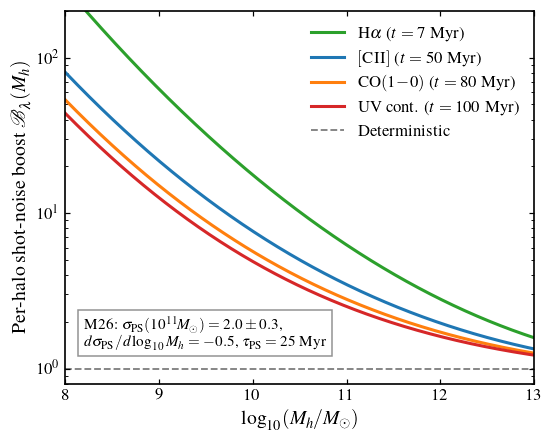

In [8]:
log10M_fine = np.linspace(8.0, 13.0, 600)
M_fine = 10**log10M_fine

fig, ax = plt.subplots(figsize=(5.5, 4.4))
for name, LP in LP_ref.items():
    ax.plot(log10M_fine, burstiness_LIM.boost_per_halo(M_fine, LP),
            color=LINE_COLOR[name], lw=2,
            label=LINE_TEX[name] + r'  ($t=%.0f$ Myr)' % t_lambda[name])
ax.axhline(1.0, color='k', ls='--', lw=1.2, alpha=0.5, label='Deterministic')
ax.set_xlabel(r'$\log_{10}(M_h / M_\odot)$')
ax.set_ylabel(r'Per-halo shot-noise boost $\mathcal{B}_\lambda(M_h)$')
ax.set_yscale('log'); ax.set_xlim(8, 13); ax.set_ylim(0.8, 200)
ax.legend(loc='upper right', fontsize=11)
ax.text(0.04, 0.10, r'M26: $\sigma_{\rm PS}(10^{11}M_\odot)=2.0\pm0.3$,' + '\n'
        + r'$d\sigma_{\rm PS}/d\log_{10}M_h=-0.5$, $\tau_{\rm PS}=25$ Myr',
        transform=ax.transAxes, fontsize=10,
        bbox=dict(facecolor='white', alpha=0.85, edgecolor='gray'))
plt.show()


---
## 6. Figure 2 — $\mathcal{B}_\lambda$ vs $\sigma_{\rm PS}$

Because the boost depends exponentially on $\sigma_x^2=\sigma_{\rm PS}^2/2$, its value is
sensitive to the assumed amplitude. The grey band marks the literature stochasticity range
$\sigma_L=0.3$–$0.5$ dex used in standard LIM forecasts; in our convention
$\sigma_{\rm PS}=\sqrt2\ln(10)\,\sigma_L$, i.e. $0.98$–$1.63$. The dotted line is the boost
that a naive $\sigma_L=0.3$ dex prescription would give.

The dense scan uses `burstiness_LIM.mass_average` with the shot-noise weight from
`coeff.shot_noise_weight(...)` — the same two quantities `B_lambda()` divides, just without
re-running the pipeline 240 times.


60 sigma_PS values x 4 lines: 0.06 s
literature sigma_L = 0.3 dex -> B_naive = 1.612; equivalent sigma_PS band 0.98 - 1.63


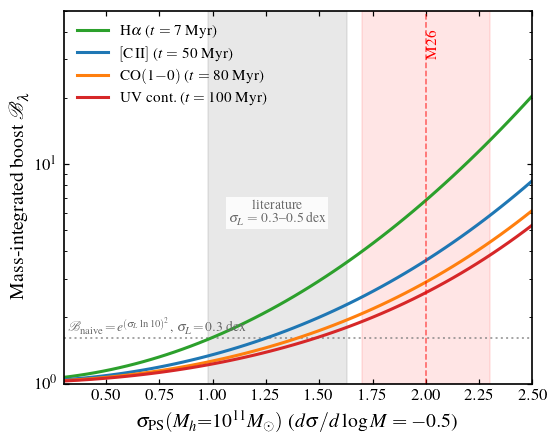

In [9]:
sigPS_grid = np.linspace(0.3, 2.5, 60)

# the weight is the deterministic shot-noise integrand: dn/dlogMh * Lbar^2
weight6 = {name: coeff_ref[name].shot_noise_weight(CP, AP, LP_ref[name], HMF,
                                                   z_Init.zintegral[iz6])
           for name in LP_ref}

t0 = time.time()
B_table = {}
for name, LP in LP_ref.items():
    B_table[name] = np.array([
        burstiness_LIM.mass_average(
            burstiness_LIM.boost_per_halo(
                HMF.Mhtab,
                Line_Parameters(LINE='SFRD', LINE_MODEL='powerlaw_SFR', _R=1.0,
                                BURSTY_FLAG=True, t_Myr_per_line=t_lambda[name],
                                sigPS_piv_bursty=s,
                                line_dict={'A_SFR': 1., 'alpha_SFR': 1.})),
            weight6[name], HMF.logtabMh)
        for s in sigPS_grid])
print(f"{len(sigPS_grid)} sigma_PS values x {len(LP_ref)} lines: {time.time()-t0:.2f} s")

sigma_PS_from_sigma_L = lambda sL: np.sqrt(2.)*np.log(10.)*sL
B_naive = np.exp((0.3*np.log(10.))**2)
print(f"literature sigma_L = 0.3 dex -> B_naive = {B_naive:.3f}; "
      f"equivalent sigma_PS band {sigma_PS_from_sigma_L(0.3):.2f} - "
      f"{sigma_PS_from_sigma_L(0.5):.2f}")

fig, ax = plt.subplots(figsize=(5.5, 4.4))
for name in LP_ref:
    ax.plot(sigPS_grid, B_table[name], color=LINE_COLOR[name], lw=2,
            label=LINE_TEX[name] + r'  ($t=%.0f$ Myr)' % t_lambda[name])
ax.axvspan(sigma_PS_from_sigma_L(0.3), sigma_PS_from_sigma_L(0.5), color='gray',
           alpha=0.18, zorder=0)
ax.text(0.5*(sigma_PS_from_sigma_L(0.3)+sigma_PS_from_sigma_L(0.5)), 6.0,
        'literature\n$\\sigma_L = 0.3$--$0.5$ dex', ha='center', va='center',
        fontsize=9, color='dimgray',
        bbox=dict(facecolor='white', alpha=0.85, edgecolor='none', pad=2))
ax.axvline(sigPS_pivot, color='red', ls='--', lw=1, alpha=0.6)
ax.text(sigPS_pivot, 30, ' M26', fontsize=10, color='red', rotation=90, va='bottom')
ax.axvspan(sigPS_pivot-sigPS_pivot_err, sigPS_pivot+sigPS_pivot_err, color='red',
           alpha=0.10, zorder=0)
ax.axhline(B_naive, color='gray', ls=':', lw=1.3, alpha=0.7, zorder=0)
ax.text(0.32, B_naive*1.04,
        r'$\mathcal{B}_{\rm naive}\!=\!e^{(\sigma_L\ln 10)^2}$, $\sigma_L\!=\!0.3$ dex',
        ha='left', va='bottom', fontsize=9, color='dimgray')
ax.set_xlabel(r'$\sigma_{\rm PS}(M_h{=}10^{11}M_\odot)$  ($d\sigma/d\log M = -0.5$)')
ax.set_ylabel(r'Mass-integrated boost $\mathcal{B}_\lambda$')
ax.set_yscale('log'); ax.set_xlim(0.3, 2.5); ax.set_ylim(1, 50)
ax.legend(loc='upper left', fontsize=10)
plt.show()


---
## 7. Figure 3 — the cross-correlation diagnostic $\mathcal{R}$

For two lines at the same redshift the cross shot noise is
$P_{\rm shot}^{\lambda_1\lambda_2}=\mathcal{X}_1\mathcal{X}_2\int{\rm d}M_h\,({\rm d}n/{\rm d}M_h)\,
\bar L_1\bar L_2\,e^{\sigma_{\xi,12}^2}$ with
$\sigma_{\xi,12}^2\equiv\ln[1+{\rm cov}(L_1,L_2)/(\bar L_1\bar L_2)]$ (Letter Eqs. 8–10). To
isolate the burst *temporal* structure from the deterministic luminosity weighting we define
the fractional excess $\Delta_{\lambda_1\lambda_2}=P^{12}_{\rm shot}/P^{12}_{\rm shot}|_{\rm det}-1$
and

$$\mathcal{R}_{\lambda_1\lambda_2}=\frac{\Delta_{\lambda_1\lambda_2}}
{\sqrt{\Delta_{\lambda_1}\Delta_{\lambda_2}}}.$$

By construction $\mathcal{R}$ is the correlation coefficient of the *bursty excess alone*:
the deterministic term divides out, the normalisation of $\bar L_\lambda$ cancels, and in the
limit of mass-independent $\sigma_{\rm PS}$ the HMF cancels exactly. The asymptotes are
$\mathcal{R}\to1$ as $\tau_{\rm PS}\to\infty$ (bursts coherent over arbitrarily long times,
so both windows see the same one) and
$\mathcal{R}\to\sqrt{\min(t_1,t_2)/\max(t_1,t_2)}$ as $\tau_{\rm PS}\to0$ (geometric window
overlap). The M26-favoured $\tau_{\rm PS}\sim10$–$50$ Myr lies in between, where the gradient
is steepest.

`Power_Spectra_LIM.R_cross(...)` returns exactly this, from the auto and cross shot-noise
integrals the code already computes.


In [10]:
pairs = [('Halpha', '[CII]',    '#1f77b4'),
         ('Halpha', 'CO(1-0)',  '#ff7f0e'),
         ('Halpha', 'UV cont.', '#2ca02c'),
         ('[CII]',  'CO(1-0)',  '#d62728'),
         ('CO(1-0)','UV cont.', '#9467bd')]

def line_at_tau(t, tau, sigPS=sigPS_pivot):
    return Line_Parameters(LINE='SFRD', LINE_MODEL='powerlaw_SFR', _R=1.0, shot_noise=True,
                           BURSTY_FLAG=True, t_Myr_per_line=t, tauPS_Myr_bursty=tau,
                           sigPS_piv_bursty=sigPS, line_dict={'A_SFR': 1., 'alpha_SFR': 1.})

def R_of(t1, t2, tau, sigPS=sigPS_pivot):
    """R from the released code path, via the auto/cross shot-noise integrals."""
    LP1, LP2 = line_at_tau(t1, tau, sigPS), line_at_tau(t2, tau, sigPS)
    c1, c2 = run_burst(LP1), run_burst(LP2)
    px = correlations_LIM.Power_Spectra_LIM(UP, CP, LP1, c1, HMFinterp=HMF, AstroParams=AP,
                                            LineParams_cross=LP2, LIMcoeffs_cross=c2,
                                            RSD_MODE=0)
    return px.R_cross(c1, c2)[iz6]

print("R at the M26 central values (tau_PS = 25 Myr, sigma_PS = 2.0):")
for a, b, _ in pairs:
    print(f"  R({a:<9s} x {b:<9s}) = {R_of(t_lambda[a], t_lambda[b], tauPS_Myr):.3f}")


R at the M26 central values (tau_PS = 25 Myr, sigma_PS = 2.0):
  R(Halpha    x [CII]    ) = 0.554
  R(Halpha    x CO(1-0)  ) = 0.430
  R(Halpha    x UV cont. ) = 0.380
  R([CII]     x CO(1-0)  ) = 0.869
  R(CO(1-0)   x UV cont. ) = 0.948


In [11]:
# ---- a fast path for the dense scans: the same functions, without re-running the
# ---- full coefficient pipeline at every grid point.
def R_fast(t1, t2, tau, sigPS, weight):
    mk = lambda t: Line_Parameters(LINE='SFRD', LINE_MODEL='powerlaw_SFR', _R=1.0,
                                   BURSTY_FLAG=True, t_Myr_per_line=t,
                                   tauPS_Myr_bursty=tau, sigPS_piv_bursty=sigPS,
                                   line_dict={'A_SFR': 1., 'alpha_SFR': 1.})
    LP1, LP2 = mk(t1), mk(t2)
    V1 = burstiness_LIM.V_lambda(HMF.Mhtab, LP1)
    V2 = burstiness_LIM.V_lambda(HMF.Mhtab, LP2)
    V12 = burstiness_LIM.V_12(HMF.Mhtab, LP1, LP2)
    return burstiness_LIM.R_cross(V1, V2, V12, weight, weight, weight, HMF.logtabMh)

w_common = weight6['Halpha']    # L ~ SFR, so the weight is the same for every line
print("cross-check of the fast path against R_cross at tau = 25 Myr:")
for a, b, _ in pairs[:2]:
    print(f"  {a:<9s} x {b:<9s}: released {R_of(t_lambda[a], t_lambda[b], tauPS_Myr):.4f}"
          f"   fast {R_fast(t_lambda[a], t_lambda[b], tauPS_Myr, sigPS_pivot, w_common):.4f}")

tau_grid = np.logspace(0.0, 3.0, 60)
t0 = time.time()
R_curves = {(a, b): np.array([R_fast(t_lambda[a], t_lambda[b], tau, sigPS_pivot, w_common)
                              for tau in tau_grid]) for a, b, _ in pairs}
log10tau_2D = np.linspace(0.0, 3.0, 30)
sigPS_2D = np.linspace(0.5, 2.5, 25)
R_grid = np.array([[R_fast(7.0, 80.0, 10**lt, s, w_common) for s in sigPS_2D]
                   for lt in log10tau_2D])
print(f"R scans ({len(tau_grid)} tau x 5 pairs, plus a {R_grid.shape} grid): "
      f"{time.time()-t0:.1f} s")


cross-check of the fast path against R_cross at tau = 25 Myr:
  Halpha    x [CII]    : released 0.5536   fast 0.5536
  Halpha    x CO(1-0)  : released 0.4303   fast 0.4303
R scans (60 tau x 5 pairs, plus a (30, 25) grid): 0.6 s


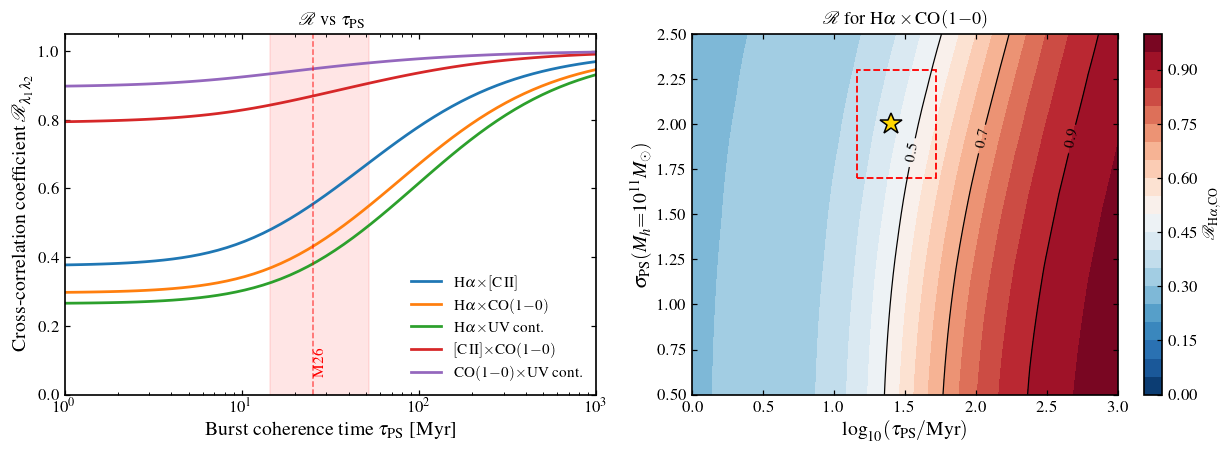

asymptote check for Halpha x CO(1-0):
  tau -> 0   : R = 0.298  (sqrt(t_min/t_max) = 0.296)
  tau -> inf : R = 0.946  (-> 1)
Near-vertical isocontours in the right panel: R depends mainly on tau_PS and only
weakly on sigma_PS, which is what makes it a clean probe of the coherence time.


In [12]:
from matplotlib.patches import Rectangle

fig, (axL, axR) = plt.subplots(1, 2, figsize=(11.5, 4.3))

for a, b, c in pairs:
    axL.semilogx(tau_grid, R_curves[(a, b)], color=c, lw=1.8,
                 label=LINE_TEX[a] + r'$\times$' + LINE_TEX[b])
tau_lo, tau_mid, tau_hi = 10**(1.40-0.24), 10**1.40, 10**(1.40+0.32)
axL.axvline(tau_mid, color='red', ls='--', lw=1, alpha=0.6)
axL.axvspan(tau_lo, tau_hi, color='red', alpha=0.10)
axL.text(tau_mid, 0.05, ' M26', fontsize=10, color='red', rotation=90, va='bottom')
axL.set_xlabel(r'Burst coherence time $\tau_{\rm PS}$ [Myr]')
axL.set_ylabel(r'Cross-correlation coefficient $\mathcal{R}_{\lambda_1\lambda_2}$')
axL.set_title(r'$\mathcal{R}$ vs $\tau_{\rm PS}$', fontsize=12)
axL.set_ylim(0, 1.05); axL.set_xlim(1.0, 1000)
axL.legend(loc='lower right', fontsize=10)

im = axR.contourf(log10tau_2D, sigPS_2D, R_grid.T, levels=np.linspace(0, 1, 21),
                  cmap='RdBu_r', vmin=0, vmax=1)
cb = plt.colorbar(im, ax=axR)
cb.set_label(r'$\mathcal{R}_{\mathrm{H}\alpha,\mathrm{CO}}$', fontsize=11)
cs = axR.contour(log10tau_2D, sigPS_2D, R_grid.T, levels=[0.5, 0.7, 0.9],
                 colors='k', linewidths=0.8)
axR.clabel(cs, inline=True, fontsize=10)
axR.plot(1.40, 2.0, marker='*', color='gold', ms=15, mec='k')
axR.add_patch(Rectangle((1.40-0.24, 2.0-0.3), 0.32+0.24, 0.6, fill=False,
                        edgecolor='red', ls='--', lw=1.2))
axR.set_xlabel(r'$\log_{10}(\tau_{\rm PS}/{\rm Myr})$')
axR.set_ylabel(r'$\sigma_{\rm PS}(M_h{=}10^{11}M_\odot)$')
axR.set_title(r'$\mathcal{R}$ for $\mathrm{H}\alpha \times \mathrm{CO}(1\!-\!0)$',
              fontsize=12)
axR.set_xlim(0, 3); axR.set_ylim(0.5, 2.5)
plt.tight_layout(); plt.show()

print("asymptote check for Halpha x CO(1-0):")
print(f"  tau -> 0   : R = {R_curves[('Halpha','CO(1-0)')][0]:.3f}  "
      f"(sqrt(t_min/t_max) = {np.sqrt(7./80.):.3f})")
print(f"  tau -> inf : R = {R_curves[('Halpha','CO(1-0)')][-1]:.3f}  (-> 1)")
print("Near-vertical isocontours in the right panel: R depends mainly on tau_PS and only")
print("weakly on sigma_PS, which is what makes it a clean probe of the coherence time.")


---
## 8. Figure 4 — LIM auto-power $\Delta^2(k)$ for H$\alpha$ at $z\approx6$

The body's main forecast figure: the H$\alpha$ auto-power at $z\approx6$, the line SPHEREx is
observing at $z=5$–$8$ and CDIM proposes to target. Three components: clustering only
(dotted), the deterministic prediction (dashed) and the M26 bursty prediction (solid), plus
the literature $\sigma_L=0.3$ dex reference.

Everything on this plot now comes from one `Power_Spectra_LIM` run per case:
$\bar I_\nu$ and the clustering term from `Deltasq_LIM`, the shot noise from
`P_shot_noise`. No hand-built $b_{\rm eff}$ or $\mathcal{X}_\lambda^2\int\bar L^2$.

**First, the convention check.** Burstiness must leave the mean intensity and the clustering
term untouched and move only the shot noise.


In [13]:
YANG_HA = dict(LINE='Ha', LINE_MODEL='Yang24', line_dict=inputs_LIM.Yang24_Ha_params)

LP_bursty = Line_Parameters(_R=1.0, shot_noise=True, BURSTY_FLAG=True, **YANG_HA)
LP_det    = Line_Parameters(_R=1.0, shot_noise=True, **YANG_HA)
c_bursty, c_det = run_burst(LP_bursty), run_burst(LP_det)
p_bursty = correlations_LIM.Power_Spectra_LIM(UP, CP, LP_bursty, c_bursty, RSD_MODE=0)
p_det    = correlations_LIM.Power_Spectra_LIM(UP, CP, LP_det,    c_det,    RSD_MODE=0)

print("Burstiness must not touch the mean or the clustering term:")
print("  Inu_bar identical         :", np.array_equal(c_bursty.Inu_bar, c_det.Inu_bar))
print("  clustering Pk identical   :", np.array_equal(p_bursty._Pk_LIM, p_det._Pk_LIM))
print(f"  P_shot ratio at z=6       : {c_bursty.shot_noise[iz6]/c_det.shot_noise[iz6]:.4f}"
      f"  = B_Halpha")
print(f"\n  Inu_bar(z=6)   = {c_bursty.Inu_bar[iz6]:.3f} Jy/sr")
print(f"  B_Halpha(z=6)  = {c_bursty.B_lambda()[iz6]:.3f}")
print(f"  equivalent sigma_L = {c_bursty.sigma_L_equivalent_dex()[iz6]:.3f} dex "
      f"(literature ansatz: 0.3-0.5)")


Burstiness must not touch the mean or the clustering term:
  Inu_bar identical         : True
  clustering Pk identical   : True
  P_shot ratio at z=6       : 7.4513  = B_Halpha

  Inu_bar(z=6)   = 16.115 Jy/sr
  B_Halpha(z=6)  = 7.451
  equivalent sigma_L = 0.615 dex (literature ansatz: 0.3-0.5)


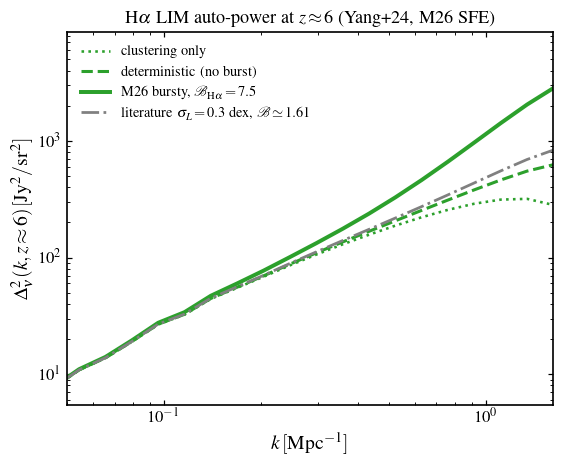

at k = 1.0 Mpc^-1:  bursty/deterministic = 2.80,  bursty/clustering-only = 3.88


In [14]:
klist = p_bursty.klist_PS
k3 = klist**3/(2*np.pi**2)
D2_clust = p_det.Deltasq_LIM[iz6]
D2_det   = p_det._Pk_LIM_tot[iz6]*k3
D2_burst = p_bursty._Pk_LIM_tot[iz6]*k3

# literature sigma_L = 0.3 dex, same line model, phenomenological scatter
LP_lit = Line_Parameters(_R=1.0, shot_noise=True, stoch_type='mean',
                         sigma_LMh_dex=0.3, **YANG_HA)
c_lit = run_burst(LP_lit)
p_lit = correlations_LIM.Power_Spectra_LIM(UP, CP, LP_lit, c_lit, RSD_MODE=0)
D2_lit = p_lit._Pk_LIM_tot[iz6]*k3
B_lit = c_lit.shot_noise[iz6]/c_det.shot_noise[iz6]

fig, ax = plt.subplots(figsize=(5.7, 4.4))
col = LINE_COLOR['Halpha']
ax.loglog(klist, D2_clust, ls=':',  color=col, lw=1.7, label='clustering only')
ax.loglog(klist, D2_det,   ls='--', color=col, lw=2.0, label='deterministic (no burst)')
ax.loglog(klist, D2_burst, ls='-',  color=col, lw=2.6,
          label=r'M26 bursty, $\mathcal{B}_{\rm H\alpha}\!=\!%.1f$'
                % c_bursty.B_lambda()[iz6])
ax.loglog(klist, D2_lit,   ls='-.', color='gray', lw=1.8,
          label=r'literature $\sigma_L\!=\!0.3$ dex, $\mathcal{B}\!\simeq\!%.2f$' % B_lit)
ax.set_xlabel(r'$k\,[{\rm Mpc}^{-1}]$')
ax.set_ylabel(r'$\Delta^2_\nu(k, z\!\approx\!6)\,[{\rm Jy^2/sr^2}]$')
ax.set_title(r'$\rm H\alpha$ LIM auto-power at $z\!\approx\!6$ (Yang+24, M26 SFE)',
             fontsize=12)
ax.set_xlim(0.05, klist.max())
vis = np.concatenate([D2_clust, D2_det, D2_burst, D2_lit])[np.concatenate([klist]*4) >= 0.05]
ax.set_ylim(vis.min()*0.5, vis.max()*3)
ax.legend(fontsize=9.5, loc='upper left')
plt.show()

kk = 1.0
print(f"at k = {kk} Mpc^-1:  bursty/deterministic = "
      f"{np.interp(kk, klist, D2_burst)/np.interp(kk, klist, D2_det):.2f},  "
      f"bursty/clustering-only = "
      f"{np.interp(kk, klist, D2_burst)/np.interp(kk, klist, D2_clust):.2f}")


### NOTE!!!
The power spectrum flattens at small k instead of steeply rising due to the density-smoothing that oLIMpus performs. Fig. 3 in the paper, instead, relies on the halo model, hence the shot noise is steeper. 

### 8.1 Why $\mathcal{B}_{{\rm H}\alpha}$ is 7.45 here and 5.7 in the Letter

The Letter's Fig. 3 caption quotes $\mathcal{B}_{{\rm H}\alpha}\simeq5.7$, and Appendix Fig. 7
quotes $\mathcal{B}_{\rm [CII]}\simeq4.3$. With the M26 SFE genuinely in place this notebook
gets **7.45** and **6.94**. Running the same calculation with oLIMpus's *default* SFE
reproduces the published numbers to three digits.

The cause is visible in the original notebook. The monkey-patch was installed and then
removed inside a `try/finally`:

```python
_orig_SFR_II = sfrd.SFR_II
sfrd.SFR_II = lambda ...: M26_SFR_appendix(M, z)
try:
    appendix_models[...] = a.run_oLIMpus(...)      # <- patch IS active here
finally:
    sfrd.SFR_II = _orig_SFR_II                     # <- patch removed

Lbar_app[name] = LineLuminosity(False, mod.LP, ...)  # <- patch is NOT active here
```

`Lbar_app` and `line_observables_at_z` — which set the $\bar L_\lambda^2\,{\rm d}n/{\rm d}\ln M_h$
weight, and hence $b_{\rm eff}$, $P_{\rm shot}|_{\rm det}$ and $\mathcal{B}$ — call
`LineLuminosity` *after* the `finally`, so they used the default SFE while $\bar I_\nu$ came
from the patched run.

The cell below shows both numbers side by side. Two independent checks confirm the diagnosis:

- $\mathcal{B}_{\rm CO(1-0)}$ is **identical** under the two SFEs, and it is the one line whose
  model (Yang+21) is a function of $M_h$ only and therefore cannot notice an SFR substitution;
- **Table I is unaffected**: it is built from the notebook's own explicit `Lbar_sfe`, not from
  `LineLuminosity`, and §10 below reproduces 6.8 / 3.6 / 2.9 / 2.6 exactly.

So what needs revisiting is the $\mathcal{B}$ values quoted in Fig. 3, Appendix Fig. 7 and
Table II — not the formalism, not Table I, and not the qualitative conclusions, which all go
the same way (the M26 SFE gives a *larger* boost).


In [15]:
AP_default = Astro_Parameters(CosmoParams=CP, **DEFAULT_SFE, **ASTRO_COMMON)
SFRD_default = SFRD_class(UP, CP, AP_default, HMF, z_Init)

line_models = {
    'Halpha':   dict(LINE='Ha',       LINE_MODEL='Yang24',    line_dict=inputs_LIM.Yang24_Ha_params),
    'OIII5007': dict(LINE='OIII5007', LINE_MODEL='Yang24',    line_dict=inputs_LIM.Yang24_OIII5007_params),
    '[CII]':    dict(LINE='CII',      LINE_MODEL='Lagache18'),
    'CO(1-0)':  dict(LINE='CO10',     LINE_MODEL='Yang21',    line_dict=inputs_LIM.Yang21_CO10_params),
}
quoted = {'Halpha': '5.7 (Fig. 3)', 'OIII5007': '-', '[CII]': '4.3 (App. Fig. 7)',
          'CO(1-0)': 'n/a at z=6'}

print(f"{'line':>9s} {'B (M26 SFE)':>13s} {'B (default SFE)':>17s}   quoted in the Letter")
print('-'*70)
appendix_models = {}
for name, kw in line_models.items():
    LPb = Line_Parameters(_R=1.0, shot_noise=True, BURSTY_FLAG=True, **kw)
    c_m26 = run_burst(LPb)
    c_def = run_burst(LPb, AstroParams=AP_default, SFRD=SFRD_default)
    appendix_models[name] = (LPb, c_m26)
    print(f"{name:>9s} {c_m26.B_lambda()[iz6]:13.3f} {c_def.B_lambda()[iz6]:17.3f}"
          f"   {quoted[name]}")
print("\nCO(1-0) is identical under the two SFEs: Yang+21 is an L(M_h) model, so it cannot")
print("see a change in the SFR -- exactly what you would expect if the substitution")
print("only ever reached the SFR-based line models.")


     line   B (M26 SFE)   B (default SFE)   quoted in the Letter
----------------------------------------------------------------------
   Halpha         7.451             5.712   5.7 (Fig. 3)
 OIII5007         6.225             4.778   -
    [CII]         6.942             4.271   4.3 (App. Fig. 7)
  CO(1-0)         1.891             1.891   n/a at z=6

CO(1-0) is identical under the two SFEs: Yang+21 is an L(M_h) model, so it cannot
see a change in the SFR -- exactly what you would expect if the substitution
only ever reached the SFR-based line models.


---
## 9. Figure 5 — redshift tomography of $\mathcal{B}_\lambda(z)$

The boost is dominated by halos near the peak of the LIM kernel
$\bar L_\lambda^2\,{\rm d}n/{\rm d}\ln M_h$. As $z$ rises the HMF cutoff $M_\star(z)$ falls,
sliding the kernel peak to lower halo masses where the M26 slope predicts larger
$\sigma_{\rm PS}$, so $\mathcal{B}_\lambda(z)$ **grows with redshift** — fastest for
H$\alpha$, which has the shortest window and therefore the steepest dependence on
$\sigma_{\rm PS}$.

This is a clean, falsifiable prediction: the *same line* observed at *different redshifts*
probes different parts of $\sigma_{\rm PS}(M_h)$, with the line itself as the calibrating
common reference. Because `B_lambda()` is already an array over `zintegral`, the whole figure
is a single call per line.

The top axis shows the kernel-peak halo mass, from `shot_noise_weight`.


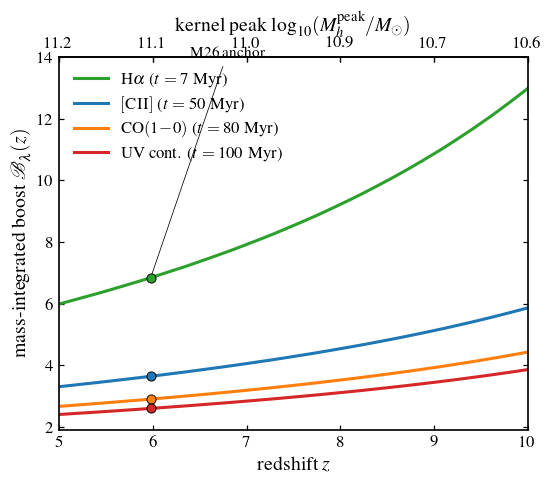

B_lambda(z):
      z     Halpha      [CII]    CO(1-0)   UV cont.
   5.00       5.98       3.30       2.66       2.40
   5.98       6.84       3.64       2.90       2.60
   7.01       7.93       4.06       3.19       2.84
   8.05       9.30       4.56       3.54       3.12
  10.02      13.03       5.88       4.43       3.87
  11.98      19.43       7.97       5.85       5.03
  14.90      39.81      14.08       9.92       8.36

Kernel-peak halo mass and sigma_PS there:
     z   log10(Mh_peak)   sigma_PS at peak
     5            11.24               1.88
     6            11.12               1.94
     7            11.00               2.00
     8            10.87               2.07
     9            10.74               2.13
    10            10.61               2.20
    12            10.32               2.34
    15             9.83               2.59

B_Halpha grows from 6.0 at z=5 to 13.0 at z=10 (factor 2.2)


In [25]:
z_arr = z_Init.zintegral
sel_z = (z_arr >= 5.0) & (z_arr <= 15.0)

fig, ax = plt.subplots(figsize=(5.5, 4.4))
for name, c in coeff_ref.items():
    ax.plot(z_arr[sel_z], c.B_lambda()[sel_z], color=LINE_COLOR[name], lw=2.0,
            label=LINE_TEX[name] + r'  ($t=%.0f$ Myr)' % t_lambda[name])
    ax.plot(z_arr[iz6], c.B_lambda()[iz6], 'o', color=LINE_COLOR[name], ms=6,
            mec='k', mew=0.6, zorder=5)
ax.annotate('M26 anchor', xy=(z_arr[iz6], coeff_ref['Halpha'].B_lambda()[iz6]),
            xytext=(6.4, 14), fontsize=10,
            arrowprops=dict(arrowstyle='-', lw=0.5, color='k'))
ax.set_ylim(1.9,14); ax.set_xlim(5.0, 10.0); 
ax.set_xlabel(r'redshift $z$')
ax.set_ylabel(r'mass-integrated boost $\mathcal{B}_\lambda(z)$')
ax.legend(loc='upper left', fontsize=11)

def kernel_peak_logM(z, name='Halpha'):
    """log10 of the halo mass where Lbar^2 dn/dlogMh peaks.

    Mhtab has ~0.26 dex spacing at precisionboost=1, so take the vertex of the parabola
    through log(weight) at the three points around the maximum rather than the grid point.
    """
    w = coeff_ref[name].shot_noise_weight(CP, AP, LP_ref[name], HMF, z)
    x = np.log10(HMF.Mhtab)
    i = int(np.argmax(w))
    if i == 0 or i == len(w) - 1:
        return x[i]
    y = np.log(w[i-1:i+2])
    curv = y[0] - 2*y[1] + y[2]
    if curv == 0:
        return x[i]
    return x[i] - 0.5*(x[i+1] - x[i-1])*0.5*(y[2] - y[0])/curv

z_ticks = [5, 6, 7, 8, 9, 10]
ax2 = ax.secondary_xaxis('top')
ax2.set_xticks(z_ticks)
ax2.set_xticklabels([f'{kernel_peak_logM(zt):.1f}' for zt in z_ticks])
ax2.set_xlabel(r'kernel peak $\log_{10}(M_h^{\rm peak}/M_\odot)$')
plt.show()

print('B_lambda(z):')
print(f'  {"z":>5}  ' + '  '.join(f'{n:>9}' for n in coeff_ref))
for zt in (5.0, 6.0, 7.0, 8.0, 10.0, 12.0, 15.0):
    j = np.argmin(abs(z_arr - zt))
    print(f'  {z_arr[j]:>5.2f}  '
          + '  '.join(f'{c.B_lambda()[j]:>9.2f}' for c in coeff_ref.values()))

print('\nKernel-peak halo mass and sigma_PS there:')
print(f'  {"z":>4}  {"log10(Mh_peak)":>15}  {"sigma_PS at peak":>17}')
for zt in (5, 6, 7, 8, 9, 10, 12, 15):
    lmp = kernel_peak_logM(float(zt))
    sp = burstiness_LIM.sigma_PS_of_M(np.array([10**lmp]), LP_ref['Halpha'])[0]
    print(f'  {zt:>4d}  {lmp:>15.2f}  {sp:>17.2f}')

Bh = coeff_ref['Halpha'].B_lambda()
j5, j10 = np.argmin(abs(z_arr-5.)), np.argmin(abs(z_arr-10.))
print(f'\nB_Halpha grows from {Bh[j5]:.1f} at z=5 to {Bh[j10]:.1f} at z=10 '
      f'(factor {Bh[j10]/Bh[j5]:.1f})')


---
## 10. Table I — boost values

Per-halo boosts at three reference masses, and the mass-integrated $\mathcal{B}_\lambda$,
at $z=6$ with oLIMpus's Sheth–Tormen HMF and the M26 SFE, under the body's
$\bar L_\lambda\propto\overline{\dot M_\star}$ ansatz.


In [17]:
ref_masses = np.array([1e9, 1e10, 1e11])
paper_T1 = {'Halpha': (63, 18, 6.2, 6.8), '[CII]': (22, 7.7, 3.5, 3.6),
            'CO(1-0)': (15, 5.7, 2.8, 2.9), 'UV cont.': (13, 4.9, 2.5, 2.6)}

print('=' * 86)
print(f'{"Line":<10s} {"(t_lambda)":>12s} ' + ' '.join(f'{"10^%d"%m:>14s}' for m in (9, 10, 11))
      + f' {"B_lambda":>14s}')
print('=' * 86)
for name, LP in LP_ref.items():
    ph = burstiness_LIM.boost_per_halo(ref_masses, LP)
    B = coeff_ref[name].B_lambda()[iz6]
    ref = paper_T1[name]
    print(f'{name:<10s} {"(%.0f Myr)"%t_lambda[name]:>12s} '
          + ' '.join(f'{ph[i]:6.1f} [{ref[i]:4.1f}]' for i in range(3))
          + f' {B:6.2f} [{ref[3]:4.1f}]')
print('=' * 86)
print('values in [brackets] are the Letter\'s Table I.')


Line         (t_lambda)           10^9          10^10          10^11       B_lambda
Halpha          (7 Myr)   62.9 [63.0]   17.6 [18.0]    6.2 [ 6.2]   6.84 [ 6.8]
[CII]          (50 Myr)   21.7 [22.0]    7.7 [ 7.7]    3.5 [ 3.5]   3.64 [ 3.6]
CO(1-0)        (80 Myr)   15.1 [15.0]    5.7 [ 5.7]    2.8 [ 2.8]   2.90 [ 2.9]
UV cont.      (100 Myr)   12.6 [13.0]    4.9 [ 4.9]    2.5 [ 2.5]   2.60 [ 2.6]
values in [brackets] are the Letter's Table I.


---
## Appendix A — line-modelling: shape modifications and scatter conventions

The body assumes the minimal $L_\lambda\propto\dot M_\star$ ansatz so that
$\mathcal{B}_\lambda$ depends only on $t_\lambda$ and the burstiness parameters. Real line
models are richer. Sorting the literature into three classes:

1. **Mean-SFR-anchored.** $L_\lambda=\kappa_\lambda\overline{\dot M_\star}$ with
   $\overline{\dot M_\star}$ tied to a UVLF-calibrated SFE. The framework used in the body.
   The boost applies cleanly: SFR scatter at fixed $M_h$ is exactly what M26 quantifies.
2. **Phenomenological $L(M_h)$ relations** — Yang+21 (CO), Yang+24 (H$\alpha$, [OIII]),
   Lagache+18 ([CII]). Deterministic $L_\lambda(M_h)$ with no explicit SFR scatter, so
   applying the boost on top is in principle clean — with the subtlety that when the
   calibration is done galaxy by galaxy on a population that includes bursty galaxies, some
   scatter is absorbed into the fitted slope. Whether that is a double count depends on
   whether the calibration sample is representative of the M26 high-burstiness regime.
3. **Direct LF-based forecasts** — COMAP/Li+16, SPHEREx/Gong+17, EXCLAIM/Pullen+23,
   CCAT/Karoumpis+22. The observed LF already contains the physical scatter; applying our
   boost there would be a re-anchoring to the M26 inference, not a correction.

**oLIMpus enforces the class-3 boundary now**: `BURSTY_FLAG=True` raises for
`LINE_MODEL='Li16'`, whose `line_dict['sigma_SFR']` is itself a lognormal SFR scatter and
would be double counted. For class-2 models the flag is allowed and the caveat above applies.

Non-burstiness scatter (dust, geometry, central–satellite splits, Ly$\alpha$ radiative
transfer) goes in through `sigma_extra_dex`, which multiplies the second moment by
$e^{(\sigma_{\rm extra}\ln10)^2}$ — the fully-time-correlated limit, reproducing the
20–30% quoted in the Discussion for 0.1–0.2 dex.

### Figure 6 — line-specific $\bar L_\lambda(M_h)$ shapes and excess kernels


In [18]:
sig_extra_check = Line_Parameters(_R=1.0, shot_noise=True, BURSTY_FLAG=True,
                                  sigma_extra_dex=0.2, **YANG_HA)
c_extra = run_burst(sig_extra_check)
print(f"non-burstiness scatter of 0.2 dex raises B_Halpha from "
      f"{c_bursty.B_lambda()[iz6]:.3f} to {c_extra.B_lambda()[iz6]:.3f} "
      f"(+{100*(c_extra.B_lambda()[iz6]/c_bursty.B_lambda()[iz6]-1):.0f}%, "
      f"Letter quotes 20-30% for 0.1-0.2 dex)")

try:
    Line_Parameters(LINE='CO21', LINE_MODEL='Li16', _R=5., shot_noise=True, BURSTY_FLAG=True)
    c_bad = run_burst(Line_Parameters(LINE='CO21', LINE_MODEL='Li16', _R=5.,
                                      shot_noise=True, BURSTY_FLAG=True))
    print("no guard against Li16 + burstiness")
except ValueError as e:
    print("\nguard:", str(e)[:100], "...")


non-burstiness scatter of 0.2 dex raises B_Halpha from 7.451 to 9.212 (+24%, Letter quotes 20-30% for 0.1-0.2 dex)

guard: BURSTY_FLAG=True is incompatible with LINE_MODEL='Li16', whose line_dict['sigma_SFR'] is itself a lo ...


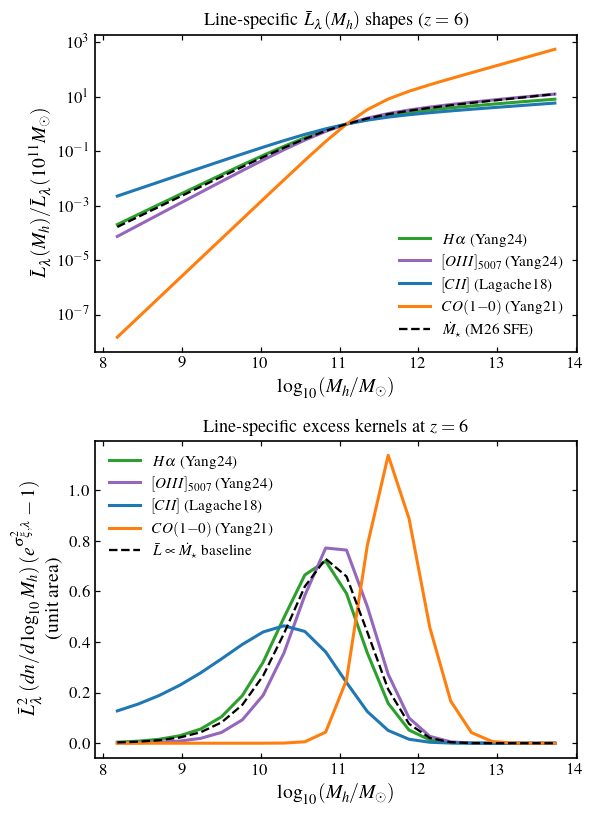

In [19]:
Mh_ap = HMF.Mhtab[(HMF.Mhtab > 1e8) & (HMF.Mhtab < 1e14)]
log10M_ap = np.log10(Mh_ap)
lnM_ap = np.log(Mh_ap)
dndlnM_ap = np.exp(HMF.logHMFint((np.log(Mh_ap), Z_BODY)))*Mh_ap

# line-specific Lbar(Mh) from the released LineLuminosity, with the M26 SFE in place
Lbar_app = {}
for name, (LPb, cb) in appendix_models.items():
    Lbar_app[name] = np.squeeze(cb.LineLuminosity(False, CP, AP, LPb, HMF,
                                                  Mh_ap[np.newaxis, :],
                                                  np.array([[Z_BODY]])))
SFR_ap = np.squeeze(SFRD_Init.SFR(CP, AP, HMF, Mh_ap[np.newaxis, :],
                                  np.array([[Z_BODY]]), 2, False, False))

t_app = {'Halpha': 7.0, 'OIII5007': 7.0, '[CII]': 50.0, 'CO(1-0)': 80.0}
col_app = {'Halpha': '#2ca02c', 'OIII5007': '#9467bd', '[CII]': '#1f77b4', 'CO(1-0)': '#ff7f0e'}
tex_app = {'Halpha': r'$H\alpha$ (Yang24)', 'OIII5007': r'$[OIII]_{5007}$ (Yang24)',
           '[CII]': r'$[CII]$ (Lagache18)', 'CO(1-0)': r'$CO(1{-}0)$ (Yang21)'}
boost_ap = {n: burstiness_LIM.boost_per_halo(Mh_ap, appendix_models[n][0]) for n in t_app}

fig, (axT, axB) = plt.subplots(2, 1, figsize=(5.6, 7.6))
i_ref = np.argmin(abs(log10M_ap - 11.0))
for name in t_app:
    axT.semilogy(log10M_ap, Lbar_app[name]/Lbar_app[name][i_ref], color=col_app[name],
                 lw=2.0, label=tex_app[name])
axT.semilogy(log10M_ap, SFR_ap/SFR_ap[i_ref], color='k', ls='--', lw=1.5,
             label=r'$\dot M_\star$ (M26 SFE)')
axT.set_xlabel(r'$\log_{10}(M_h/M_\odot)$')
axT.set_ylabel(r'$\bar L_\lambda(M_h)/\bar L_\lambda(10^{11}M_\odot)$')
axT.set_title(r'Line-specific $\bar L_\lambda(M_h)$ shapes ($z=6$)', fontsize=12)
axT.legend(loc='lower right', fontsize=10)

for name in t_app:
    K = Lbar_app[name]**2*dndlnM_ap*(boost_ap[name] - 1.0)
    axB.plot(log10M_ap, K/np.trapezoid(K, log10M_ap), color=col_app[name], lw=2.0,
             label=tex_app[name])
Kb = SFR_ap**2*dndlnM_ap*(boost_ap['Halpha'] - 1.0)
axB.plot(log10M_ap, Kb/np.trapezoid(Kb, log10M_ap), color='k', ls='--', lw=1.5,
         label=r'$\bar L\propto\dot M_\star$ baseline')
axB.set_xlabel(r'$\log_{10}(M_h/M_\odot)$')
axB.set_ylabel(r'$\bar L_\lambda^2\,(dn/d\log_{10}M_h)\,(e^{\sigma_{\xi,\lambda}^2}-1)$'
               '\n(unit area)')
axB.set_title(r'Line-specific excess kernels at $z=6$', fontsize=12)
axB.legend(loc='upper left', fontsize=10)
plt.tight_layout(); plt.show()


### Table II — $\mathcal{B}_\lambda$ under line-specific shapes vs the $L\propto\dot M_\star$ baseline

For each line, $\mathcal{B}_\lambda$ at $z=6$ under (a) the body's $L\propto\dot M_\star$
ansatz and (b) the line-specific $\bar L_\lambda(M_h)$. Same $t_\lambda$, same HMF, same
$\sigma_{\rm PS}(M_h)$; only the kernel weight changes.

Note this table is now a **clean** comparison. In the Letter's notebook the two columns also
differed by the SFE (§8.1) — the baseline used the explicit M26 `Lbar_sfe` while the
line-specific column used `LineLuminosity` with the default SFE — so part of what was
attributed to line shape was the SFE substitution. With both columns on the M26 SFE the
spread is $-35\%$ to $+66\%$, wider than the $-35\%$ to $+17\%$ quoted, and driven by
[CII]: the Lagache+18 sublinear low-mass slope pushes its kernel to lower halo mass than any
of the other shapes, straight into the region where $\sigma_{\rm PS}$ is largest. That is the
same mechanism the cap test in Appendix C picks up, and it is worth saying out loud in the
paper: [CII] is the line whose boost is most sensitive to the low-mass extrapolation.


In [20]:
print(f'{"Line":<10} {"t_l":>5} {"B (L prop SFR)":>16} {"B (line shape)":>16} {"diff":>8}')
print('-'*60)
for name, t in t_app.items():
    w_uni = SFR_ap**2*dndlnM_ap
    w_line = Lbar_app[name]**2*dndlnM_ap
    b = boost_ap[name]
    B_uni = burstiness_LIM.mass_average(b, w_uni, lnM_ap)
    B_line = burstiness_LIM.mass_average(b, w_line, lnM_ap)
    print(f'{name:<10} {t:>5.0f} {B_uni:>16.3f} {B_line:>16.3f} '
          f'{100*(B_line/B_uni-1):>7.1f}%')


Line         t_l   B (L prop SFR)   B (line shape)     diff
------------------------------------------------------------
Halpha         7            6.855            7.464     8.9%
OIII5007       7            6.855            6.242    -9.0%
[CII]         50            3.646            6.043    65.7%
CO(1-0)       80            2.903            1.894   -34.8%


### Figure 7 — realistic forecast: [CII] at $z=6$ and CO(1–0) at $z=3$

The body's Fig. 4 shows H$\alpha$ at $z=6$ (SPHEREx). Other experiments target different
lines at different redshifts: [CII] at $z\sim6$ (TIME, EXCLAIM, CONCERTO, CCAT/FYST) and
CO(1–0) at $z=2.4$–$3.4$ (COMAP Pathfinder, the peak of cosmic star formation).

- **[CII] at $z=6$**: the Lagache+18 sublinear low-mass slope shifts the kernel to lower-mass
  halos with larger $\sigma_{\rm PS}$. The high mean intensity (Visbal–Loeb
  $\bar I\propto\rho_L/\nu_{\rm rest}$ favours low-frequency lines) keeps clustering
  competitive with shot noise across the accessible range, so the bursty enhancement shows up
  mainly at the highest $k$.
- **CO(1–0) at $z=3$**: the lower redshift puts the kernel peak at $\sim10^{12}M_\odot$ where
  $\sigma_{\rm PS}$ is much smaller, and the long Yang+21 window reduces the boost further.
  Yang+21's steep low-mass cutoff puts $\bar I_{\rm CO}$ on the conservative end of the
  literature spread, well below the COMAP Season 2 upper limit.

The Letter's notebook computed the $z=3$ point by hand (Visbal–Loeb $\bar I$, a growth-factor
rescaling of $\Delta^2_m$, and a second HMF interpolator) because `run_oLIMpus` hard-codes
`zmin_CLASS = 5`. That is not necessary: `Cosmo_Parameters(zmin_CLASS=2.5)` extends the whole
pipeline. Two traps to know about when you lower the redshift floor:

- **Both** `User_Parameters(zmin=...)` and `Cosmo_Parameters(zmin_CLASS=...)` must be lowered.
  The HMF tables follow `zmin_CLASS`; lowering only `zmin` gives NaN below $z=5$.
- The `UserParams` you pass to `get_LIM_coefficients` must be the *same* one the `Z_init`
  came from. $\rho_L$ is tabulated on `geomspace(UserParams.zmin, zmax_AstroBreak)` and then
  interpolated onto `z_Init.zintegral`; mixing a `zmin=5` `UserParams` with a `zmin=2.5`
  `Z_init` used to return $\rho_L=0$ — and hence $\bar I_\nu=0$ — below $z=5$, silently.
  That interpolator now has `bounds_error=True` and raises instead.


low-z pipeline (zmin = 2.5): 10.7 s; zintegral down to 2.50
  [CII]    z=6.03:  Ibar = 562 Jy/sr,  B = 7.02
  CO(1-0)  z=2.99:  Ibar = 74.83 Jy/sr,  B = 1.60


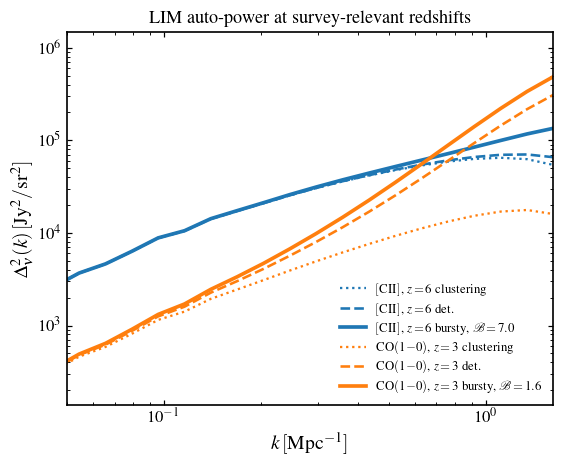

In [21]:
t0 = time.time()
UP_lo = User_Parameters(precisionboost=1.0, FLAG_FORCE_LINEAR_CF=False, MIN_R_NONLINEAR=0.5,
                        MAX_R_NONLINEAR=200.0, FLAG_DO_DENS_NL=False,
                        FLAG_WF_ITERATIVE=True, zmin=2.5)
CP_lo = Cosmo_Parameters(UserParams=UP_lo, omegab=0.0223828, omegac=0.1201075, h_fid=0.67810,
                         As=2.100549e-09, ns=0.9660499, tau_fid=0.05430842, HMF_CHOICE="ST",
                         zmin_CLASS=2.5)
HMF_lo = cosmology.HMF_interpolator(UserParams=UP_lo, CosmoParams=CP_lo)
AP_lo = Astro_Parameters(CosmoParams=CP_lo, **M26_SFE, **ASTRO_COMMON)
zI_lo = Z_init(UserParams=UP_lo, CosmoParams=CP_lo)
SFRD_lo = SFRD_class(UP_lo, CP_lo, AP_lo, HMF_lo, zI_lo)
print(f"low-z pipeline (zmin = 2.5): {time.time()-t0:.1f} s; zintegral down to "
      f"{zI_lo.zintegral.min():.2f}")

specs = []
for name, z_obs, kw, color in [('[CII]', 6.0, line_models['[CII]'], '#1f77b4'),
                               ('CO(1-0)', 3.0, line_models['CO(1-0)'], '#ff7f0e')]:
    LPb = Line_Parameters(_R=1.0, shot_noise=True, BURSTY_FLAG=True, **kw)
    LPd = Line_Parameters(_R=1.0, shot_noise=True, **kw)
    cb = run_burst(LPb, AstroParams=AP_lo, SFRD=SFRD_lo, CosmoParams=CP_lo,
                   HMFinterp=HMF_lo, ZI=zI_lo, UserParams=UP_lo)
    cd = run_burst(LPd, AstroParams=AP_lo, SFRD=SFRD_lo, CosmoParams=CP_lo,
                   HMFinterp=HMF_lo, ZI=zI_lo, UserParams=UP_lo)
    pb = correlations_LIM.Power_Spectra_LIM(UP_lo, CP_lo, LPb, cb, RSD_MODE=0)
    pd = correlations_LIM.Power_Spectra_LIM(UP_lo, CP_lo, LPd, cd, RSD_MODE=0)
    j = np.argmin(abs(cb.zintegral - z_obs))
    specs.append((name, z_obs, color, cb, pb, pd, j))
    print(f"  {name:<8s} z={cb.zintegral[j]:.2f}:  Ibar = {cb.Inu_bar[j]:.4g} Jy/sr,  "
          f"B = {cb.B_lambda()[j]:.2f}")

fig, ax = plt.subplots(figsize=(5.7, 4.4))
for name, z_obs, color, cb, pb, pd, j in specs:
    k = pb.klist_PS; k3l = k**3/(2*np.pi**2)
    tex = LINE_TEX[name] + r', $z\!=\!%g$' % z_obs
    ax.loglog(k, pd.Deltasq_LIM[j],       ls=':',  color=color, lw=1.5, label=f'{tex} clustering')
    ax.loglog(k, pd._Pk_LIM_tot[j]*k3l,   ls='--', color=color, lw=1.7, label=f'{tex} det.')
    ax.loglog(k, pb._Pk_LIM_tot[j]*k3l,   ls='-',  color=color, lw=2.4,
              label=rf'{tex} bursty, $\mathcal{{B}}\!=\!{cb.B_lambda()[j]:.1f}$')
ax.set_xlabel(r'$k\,[{\rm Mpc}^{-1}]$')
ax.set_ylabel(r'$\Delta^2_\nu(k)\,[{\rm Jy^2/sr^2}]$')
ax.set_title('LIM auto-power at survey-relevant redshifts', fontsize=12)
ax.set_xlim(0.05, pb.klist_PS.max())
vis = []
for name, z_obs, color, cb, pb_, pd_, j in specs:
    k = pb_.klist_PS; m = k >= 0.05; k3l = k**3/(2*np.pi**2)
    vis += [pd_.Deltasq_LIM[j][m], (pd_._Pk_LIM_tot[j]*k3l)[m], (pb_._Pk_LIM_tot[j]*k3l)[m]]
vis = np.concatenate(vis); vis = vis[np.isfinite(vis) & (vis > 0)]
ax.set_ylim(vis.min()*0.3, vis.max()*3)
ax.legend(fontsize=8.5, loc='lower right', ncol=1)
plt.show()


---
## Appendix C — the $\sigma_{\rm PS}\gtrsim3$ cap

Sufficiently large bursts are physically self-limiting: such amplitudes would consume a
low-mass halo's cold gas within the burst-coherence time, and the lognormal description of
the SFR PDF is expected to break down. Under the M26 slope the kernel peak slides to lower
mass at higher $z$, pushing part of the integrand above $\sigma_{\rm PS}=3$
($M_h\lesssim10^9M_\odot$).

`sigPS_max_bursty` imposes the cap. The table below recomputes $\mathcal{B}_\lambda(z)$ with
and without it, under the line-specific $\bar L_\lambda(M_h)$ shapes.


In [22]:
z_cap = np.array([6.0, 7.0, 8.0, 9.0, 10.0])
print(f"Cap-vs-uncap shift in B_lambda, cap at sigma_PS = 3\n")
print(f"{'line':>10}  " + "  ".join(f"z={z:.0f}" for z in z_cap))
print('-'*56)
for name, kw in line_models.items():
    LPu = Line_Parameters(_R=1.0, shot_noise=True, BURSTY_FLAG=True, **kw)
    LPc = Line_Parameters(_R=1.0, shot_noise=True, BURSTY_FLAG=True,
                          sigPS_max_bursty=3.0, **kw)
    cu, cc = run_burst(LPu), run_burst(LPc)
    Bu, Bc = cu.B_lambda(), cc.B_lambda()
    shifts = []
    for z in z_cap:
        j = np.argmin(abs(cu.zintegral - z))
        shifts.append(100.*(Bc[j]/Bu[j] - 1.))
    print(f"{name:>10}  " + "  ".join(f"{s:+5.1f}%" for s in shifts))

print(f"\n{'line':>10}  kernel-peak log10(Mh) per z")
print('-'*56)
for name, kw in line_models.items():
    LPu, cu = appendix_models[name]
    peaks = []
    for z in z_cap:
        w = cu.shot_noise_weight(CP, AP, LPu, HMF, z)
        peaks.append(np.log10(HMF.Mhtab[np.argmax(w)]))
    print(f"{name:>10}  " + "  ".join(f"{p:5.1f} " for p in peaks))
print("\nsigma_PS = 3 corresponds to M_h = 1e9 Msun.")


Cap-vs-uncap shift in B_lambda, cap at sigma_PS = 3

      line  z=6  z=7  z=8  z=9  z=10
--------------------------------------------------------
    Halpha   -0.4%   -0.8%   -1.4%   -2.4%   -3.9%
  OIII5007   -0.1%   -0.2%   -0.3%   -0.6%   -1.0%
     [CII]  -15.7%  -22.6%  -31.3%  -41.1%  -50.6%
   CO(1-0)   -0.0%   -0.0%   -0.0%   -0.0%   -0.0%

      line  kernel-peak log10(Mh) per z
--------------------------------------------------------
    Halpha   11.1    10.8    10.8    10.6    10.6 
  OIII5007   11.1    11.1    10.8    10.8    10.6 
     [CII]   10.8    10.6    10.6    10.3    10.0 
   CO(1-0)   11.6    11.6    11.4    11.4    11.4 

sigma_PS = 3 corresponds to M_h = 1e9 Msun.


---
## Summary of what changed relative to the Letter's companion notebook

**Reproduced exactly**

- per-halo boosts, Table I: 63 / 18 / 6.2 for H$\alpha$ at $10^9/10^{10}/10^{11}M_\odot$, and the
  same for the other three lines;
- mass-integrated Table I values 6.8 / 3.6 / 2.9 / 2.6;
- $\mathcal{R}$ at the M26 central values and both asymptotes;
- $\mathcal{B}_{\rm CO}=1.60$ at $z=3$;
- the top-hat vs exponential kernel comparison.

**Changed**

- $\mathcal{B}_{{\rm H}\alpha}=7.45$ and $\mathcal{B}_{\rm [CII]}=6.94$ with the M26 SFE
  actually applied, against the 5.7 and 4.3 quoted; see §8.1. Both move *up*, so the Letter's
  conclusions strengthen rather than weaken.

**Removed**

- the `sfrd.SFR_II` monkey-patch (the M26 SFE is ordinary `Astro_Parameters`);
- hand-rolled $V_\lambda$, $V_{12}$, $b_{\rm eff}$, $P_{\rm shot}|_{\rm det}$,
  $\mathcal{B}$, $\mathcal{R}$;
- the second HMF interpolator for $z=3$;
- adaptive quadrature: both $V$ integrals are now closed form, exact to $5\times10^{-14}$ and
  vectorised over halo mass.

**Guards added to the code**

- `BURSTY_FLAG=True` raises with `stoch_type='median'` or `sigma_LMh_dex != 0` (double count);
- and with `LINE_MODEL='Li16'`, whose `sigma_SFR` is itself an SFR scatter;
- `tauPS_Myr_bursty` must match between two cross-correlated lines.
